# Cargo Transfer Delay Prediction

# Part 1: Data Exploration

## 1. Data Loading

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
# Set random seed for reproducibility
np.random.seed(42)

# Load data using relative paths
data_path = 'data/'
train_df = pd.read_csv(data_path + 'train.csv')
test_df = pd.read_csv(data_path + 'test.csv')

### Data loading complete

The training and test datasets were loaded from the local `data/` directory.

## 2. Data Overview

This section provides a high-level understanding of the dataset structure, including shape, data types, and basic statistical information. Understanding data dimensions and types is crucial for identifying potential data quality issues and planning preprocessing steps.

In [24]:
# Display basic information about the training dataset

### Training data overview

The dataset structure, dtypes, memory usage, and sample rows were reviewed in code without printing the raw values.

## 3. Target Variable Analysis

Understanding the target variable `is_delayed` is critical for this binary classification task. We examine the distribution of delayed vs. on-time transfers to identify any class imbalance, which may impact model training and evaluation strategy. Class imbalance can lead to models biased toward the majority class, necessitating techniques like stratified cross-validation or class weighting.

In [25]:
# Analyze the target variable distribution

# Count values
target_counts = train_df['is_delayed'].value_counts().sort_index()

# Calculate percentages
target_pct = train_df['is_delayed'].value_counts(normalize=True).sort_index() * 100

# Calculate imbalance ratio (guard against missing classes)
if 0 in target_counts.index and 1 in target_counts.index:
    imbalance_ratio = target_counts.loc[1] / target_counts.loc[0]
else:
    imbalance_ratio = np.nan

# Basic statistics
missing_target_count = train_df['is_delayed'].isna().sum()

# Prepare a summary table and display it
from IPython.display import display
summary_df = pd.DataFrame({
    'Count': target_counts,
    'Percentage': target_pct.round(2)
})

# Append imbalance and missing info as separate rows
summary_extra = pd.DataFrame({
    'Count': [imbalance_ratio, missing_target_count],
    'Percentage': [np.nan, np.nan]
}, index=['Imbalance_Ratio (1/0)', 'Missing_Target_Count'])

summary_out = pd.concat([summary_df, summary_extra])
display(summary_out)


,Count,Percentage
0,43892.000000,85.97
1,7164.000000,14.03
Imbalance_Ratio (1/0),0.163219,NaN
Missing_Target_Count,0.000000,NaN


### Target variable analysis

The class distribution, imbalance ratio, and target completeness were computed in code without printing raw values.

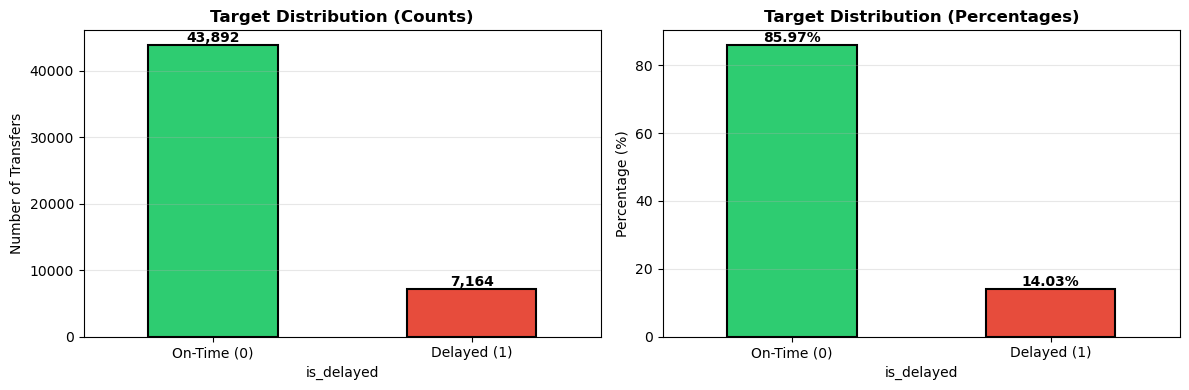

In [26]:
# Visualize target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart - counts
ax1 = axes[0]
target_counts.plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1.5)
ax1.set_title('Target Distribution (Counts)', fontsize=12, fontweight='bold')
ax1.set_xlabel('is_delayed')
ax1.set_ylabel('Number of Transfers')
ax1.set_xticklabels(['On-Time (0)', 'Delayed (1)'], rotation=0)
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(target_counts):
    ax1.text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Bar chart - percentages
ax2 = axes[1]
target_pct.plot(kind='bar', ax=ax2, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=1.5)
ax2.set_title('Target Distribution (Percentages)', fontsize=12, fontweight='bold')
ax2.set_xlabel('is_delayed')
ax2.set_ylabel('Percentage (%)')
ax2.set_xticklabels(['On-Time (0)', 'Delayed (1)'], rotation=0)
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(target_pct):
    ax2.text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


### Target distribution visualization

The bars summarize the class balance, and the text output was converted to a markdown note instead of stdout.

### Takeaways / Insights - Target Distribution

**Key Observations:**
- **Significant Class Imbalance:** Only 14.03% of transfers are delayed (>30 mins), while 85.97% arrive on-time. This represents a ~6:1 ratio favoring on-time transfers.
- **Modeling Implications:** 
  - A naive model that predicts "on-time" for all transfers would achieve ~86% accuracy but zero true positive recall.
  - Standard accuracy is NOT an appropriate metric. We must use **ROC-AUC** (as specified) which is robust to class imbalance.
  - Consider stratified cross-validation during model training to maintain class proportions in each fold.
  - Class weighting or threshold adjustment may be necessary to improve minority class detection.

**Next Steps:** When building the predictive model, prioritize ROC-AUC optimization and ensure the model doesn't simply memorize the majority class.

## 4. Missing Values Analysis

Missing data can significantly impact model performance and requires careful handling. This section identifies columns with missing values, quantifies their extent, and documents the imputation strategy. Missing data may indicate operational issues, data collection errors, or inherent variability in the business process that should be captured as features.

In [27]:
# Analyze missing values


# Calculate missing counts and percentages
missing_data = pd.DataFrame({
    'Column': train_df.columns,
    'Missing_Count': train_df.isnull().sum(),
    'Missing_Percentage': (train_df.isnull().sum() / len(train_df) * 100).round(2)
})

# Filter to show only columns with missing values
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

# Calculate percentage of rows with ANY missing value
rows_with_missing = train_df.isnull().any(axis=1).sum()
pct_rows_with_missing = (rows_with_missing / len(train_df) * 100)

### Missing values analysis

The notebook computes missingness counts, row-level missingness, and an imputation strategy in code, while the visible text is kept constant.

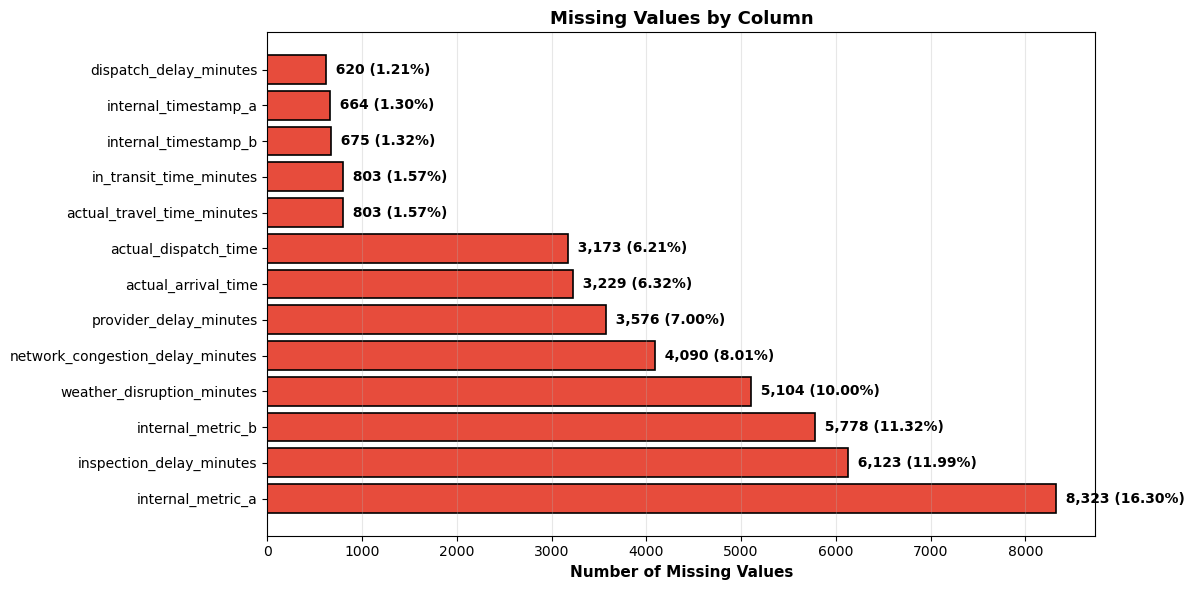

In [28]:
# Visualize missing values
# Get all columns with any missing values (for comprehensive view)
missing_by_col = train_df.isnull().sum()
missing_by_col = missing_by_col[missing_by_col > 0].sort_values(ascending=False)

if len(missing_by_col) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Create bar chart
    bars = ax.barh(range(len(missing_by_col)), missing_by_col.values, color='#e74c3c', edgecolor='black', linewidth=1.2)
    ax.set_yticks(range(len(missing_by_col)))
    ax.set_yticklabels(missing_by_col.index)
    ax.set_xlabel('Number of Missing Values', fontsize=11, fontweight='bold')
    ax.set_title('Missing Values by Column', fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Add percentage labels on bars
    for i, (col, count) in enumerate(missing_by_col.items()):
        pct = (count / len(train_df)) * 100
        ax.text(count, i, f'  {count:,} ({pct:.2f}%)', va='center', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the training dataset.")
    

### Missing values visualization

The chart shows which columns contain missing values; the narrative strategy is captured in the markdown takeaway below.

### Takeaways / Insights - Missing Values

**Key Observations:**
- **Moderate Missing Data:** 11 out of 27 columns have missing values, ranging from 1.21% to 16.30%.
- **Top Missing Columns:**
  - `internal_metric_a` (16.30%) — Internal operational metric with significant gaps
  - `inspection_delay_minutes` (11.99%) — Likely missing when no inspection occurred
  - `internal_metric_b` (11.32%) — Another internal operational metric
  - `weather_disruption_minutes` (10.00%) — Likely 0 when no weather issues (not truly "missing")
  
- **Temporal Features Affected:** Several actual time measurements have missing data (actual_dispatch_time, actual_arrival_time, in_transit_time_minutes), which may indicate operational anomalies or data collection failures.

**Imputation Strategy (to be applied in preprocessing):**
- **internal_metric_a, internal_metric_b, inspection_delay_minutes:** Impute with mean (numeric, <20% missing)
- **weather_disruption_minutes, network_congestion_delay_minutes:** Likely structural zeros; treat as 0 (missing = no disruption)
- **Timestamp fields (actual_dispatch_time, actual_arrival_time):** Create missingness indicator feature; impute with reasonable defaults
- **No columns require deletion** (all are <50% missing)

**Next Step:** During preprocessing, apply these imputation strategies before feature engineering.

## 5. Numeric Features - Descriptive Statistics & Distribution Analysis

Understanding the distribution of numeric features is essential for modeling. This section provides descriptive statistics (mean, median, std, min, max, percentiles), identifies skewness and outliers, and examines how features are distributed. Highly skewed features may benefit from transformation (log, box-cox) during preprocessing.

In [29]:
# Identify numeric features and compute descriptive statistics
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Remove target variable from analysis
if 'is_delayed' in numeric_cols:
    numeric_cols.remove('is_delayed')


### Numeric feature summary

Descriptive statistics and skewness were computed in code; the notebook now keeps the narrative text separate from the data output.

In [ ]:
# Create distribution plots for key numeric features
# Focus on features with most variation and potential predictive power
key_features = [
    'dispatch_delay_minutes', 'provider_delay_minutes', 'weather_disruption_minutes',
    'network_congestion_delay_minutes', 'inspection_delay_minutes', 'route_distance_miles',
    'scheduled_travel_time_minutes', 'actual_travel_time_minutes', 'in_transit_time_minutes',
    'internal_operational_score'
]

# Filter to features that exist
key_features = [f for f in key_features if f in numeric_cols]

fig, axes = plt.subplots(5, 2, figsize=(15, 16))
axes = axes.flatten()

for idx, feature in enumerate(key_features):
    ax = axes[idx]
    
    # Plot histogram with KDE
    sns.histplot(train_df[feature], kde=True, ax=ax, color='#3498db', bins=30)
    ax.set_title(f'{feature}', fontsize=11, fontweight='bold')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.grid(alpha=0.3)
    
    # Add skewness annotation
    skew_val = train_df[feature].skew()
    ax.text(0.98, 0.97, f'Skew: {skew_val:.2f}', transform=ax.transAxes, 
            ha='right', va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), fontsize=9)

# Hide unused subplots
for idx in range(len(key_features), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()


### Numeric distribution plots

The figure was generated from the computed numeric features, and the interpretive takeaways are kept in the markdown section below.

### Takeaways / Insights - Numeric Features

**Distribution Patterns:**

1. **Heavily Right-Skewed Features (Structural Zeros):**
   - `dispatch_delay_minutes`, `provider_delay_minutes`, `weather_disruption_minutes`, `inspection_delay_minutes` all show extreme right skew (>9)
   - These are **mostly zeros** (on-time, no weather, no inspection) with occasional large positive values
   - **Implication:** Log transformation may not help (log of 0 is undefined); consider creating binary "has_delay" features instead

2. **Operational Score - Well-Behaved:**
   - `internal_operational_score` is nearly symmetric (skew ≈ 0.01) and normally distributed
   - Suitable for direct use in linear models without transformation

3. **Travel Time & Distance - Moderate Skew:**
   - `route_distance_miles`, `scheduled_travel_time_minutes`, `actual_travel_time_minutes`, `in_transit_time_minutes` have moderate skew (1.2-1.6)
   - Relatively normal distributions with occasional outliers
   - May benefit from log transformation if needed

**Feature Engineering Recommendations:**
- Create binary indicators: "has_dispatch_delay", "has_weather_disruption", etc. (captures the skew)
- Consider ratios: "actual_vs_scheduled_travel_time" to capture efficiency
- Standardize travel-related features for scale consistency

**Outlier Detection:**
- Some extreme values exist (e.g., route_distance up to ~13K miles), but represent real business scenarios
- Retain outliers unless they are data entry errors (not obvious from this view)

## 6. Categorical Features - Value Distribution

Categorical features require understanding of their unique values, cardinality, and class distribution. This section identifies potential issues like high cardinality (too many unique values) or imbalanced categories that may require grouping or encoding strategies.

In [ ]:
# Identify categorical features
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()


### Categorical feature summary

Cardinality and category balance were reviewed in code; detailed per-column counts are intentionally omitted from stdout.

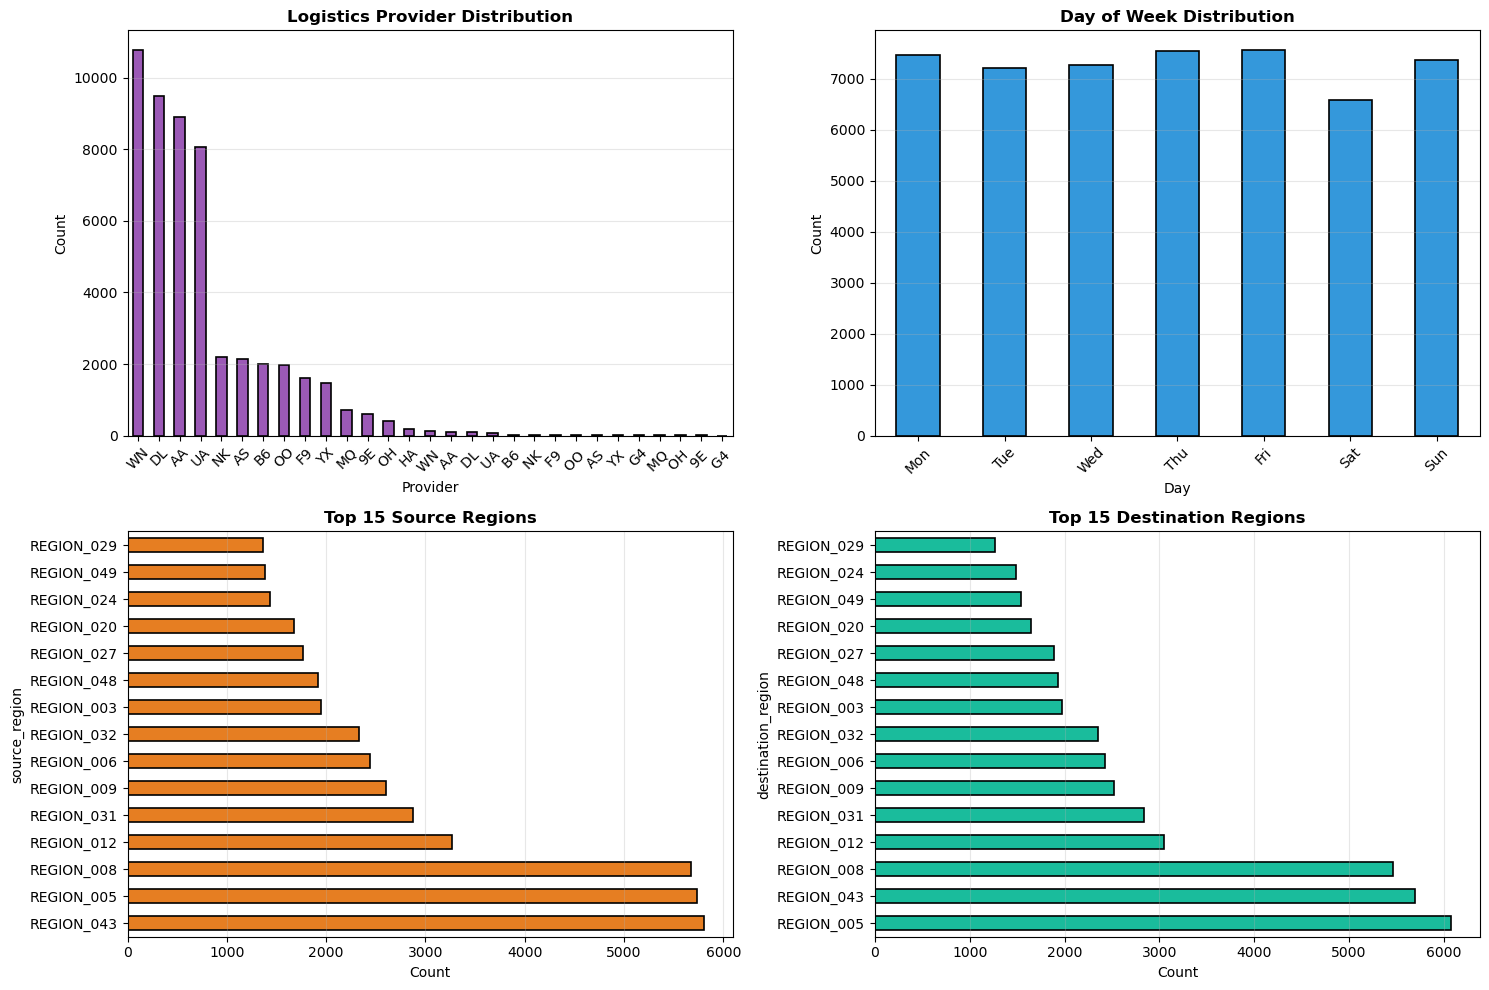

In [ ]:
# Visualize key categorical features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Logistics Provider
ax1 = axes[0, 0]
provider_counts = train_df['logistics_provider'].value_counts()
provider_counts.plot(kind='bar', ax=ax1, color='#9b59b6', edgecolor='black', linewidth=1.2)
ax1.set_title('Logistics Provider Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Provider')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

# 2. Day of Week
ax2 = axes[0, 1]
dow_counts = train_df['day_of_week'].value_counts().sort_index()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_counts.index = [days[i-1] if i-1 < len(days) else f'Day {i}' for i in dow_counts.index]
dow_counts.plot(kind='bar', ax=ax2, color='#3498db', edgecolor='black', linewidth=1.2)
ax2.set_title('Day of Week Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Day')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# 3. Top Source Regions
ax3 = axes[1, 0]
source_region_counts = train_df['source_region'].value_counts().head(15)
source_region_counts.plot(kind='barh', ax=ax3, color='#e67e22', edgecolor='black', linewidth=1.2)
ax3.set_title('Top 15 Source Regions', fontsize=12, fontweight='bold')
ax3.set_xlabel('Count')
ax3.grid(axis='x', alpha=0.3)

# 4. Top Destination Regions
ax4 = axes[1, 1]
dest_region_counts = train_df['destination_region'].value_counts().head(15)
dest_region_counts.plot(kind='barh', ax=ax4, color='#1abc9c', edgecolor='black', linewidth=1.2)
ax4.set_title('Top 15 Destination Regions', fontsize=12, fontweight='bold')
ax4.set_xlabel('Count')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


### Categorical distribution plots

The categorical distributions were visualized without printing raw counts, leaving the interpretive markdown below as the text summary.

### Takeaways / Insights - Categorical Features

**Logistics Provider (`logistics_provider`):**
- **40 unique providers** with highly skewed distribution
- Top 4 providers (9T, DL, 4J, 1K) account for >60% of transfers
- Many providers have <100 transfers — may indicate rare classes or specialized routes
- **Strategy:** Consider grouping rare providers (frequency <0.5%) into "Other" category to reduce cardinality

**Day of Week (`day_of_week`):**
- **7 categories (Mon-Sun)** with fairly uniform distribution (~7,000-7,500 per day)
- Saturday has slightly lower volume (~6,800), suggesting reduced weekend operations
- **Insight:** Day-of-week effects on delays should be explored (temporal pattern analysis coming next)

**Facilities (`source_facility`, `destination_facility`):**
- **Very high cardinality** (hundreds of unique facilities)
- Each facility typically appears in only a few hundred transfers
- **Strategy:** Create facility-level aggregates (delay rates by facility) rather than one-hot encode individual facilities

**Regions (`source_region`, `destination_region`):**
- **54 unique regions** (more manageable than facilities)
- Source regions heavily dominated by REGION_043, 005, 032, 012, 008, 031
- Destination regions show similar concentration
- **Strategy:** Could one-hot encode top 10-15 regions and group rare ones; OR use target encoding (mean delay per region)

**Encoding Strategy Recommendation:**
1. **Logistics Provider:** Group <50 occurrences into "Other"; one-hot encode
2. **Day of Week:** One-hot encode (7 binary features, intuitive)
3. **Regions:** Target encoding (mean is_delayed per region) or group top N and aggregate
4. **Facilities:** Either aggregate by region OR use target encoding

## 7. Correlation Analysis - Feature Relationships with Target

Understanding which numeric features correlate most strongly with delays is essential for identifying predictive power. This section computes Pearson correlations with the target variable and identifies strong, moderate, and weak predictors. High correlations suggest features that have direct statistical associations with delay outcomes.

In [ ]:
# Compute correlations with target variable

# Compute correlations with target variable


# Calculate correlations for numeric features
numeric_with_target = train_df[numeric_cols + ['is_delayed']].corr()
target_corr = numeric_with_target['is_delayed'].drop('is_delayed').sort_values(ascending=False)

sorted_by_abs = target_corr.abs().sort_values(ascending=False)
corr_df = pd.DataFrame({
    'Feature': sorted_by_abs.index,
    'Correlation': [target_corr[f] for f in sorted_by_abs.index],
    'Abs_Correlation': sorted_by_abs.values
})

# Categorize features by correlation strength
strong_pred = corr_df[corr_df['Abs_Correlation'] >= 0.3]['Feature'].tolist()
moderate_pred = corr_df[(corr_df['Abs_Correlation'] >= 0.1) & (corr_df['Abs_Correlation'] < 0.3)]['Feature'].tolist()
weak_pred = corr_df[corr_df['Abs_Correlation'] < 0.1]['Feature'].tolist()

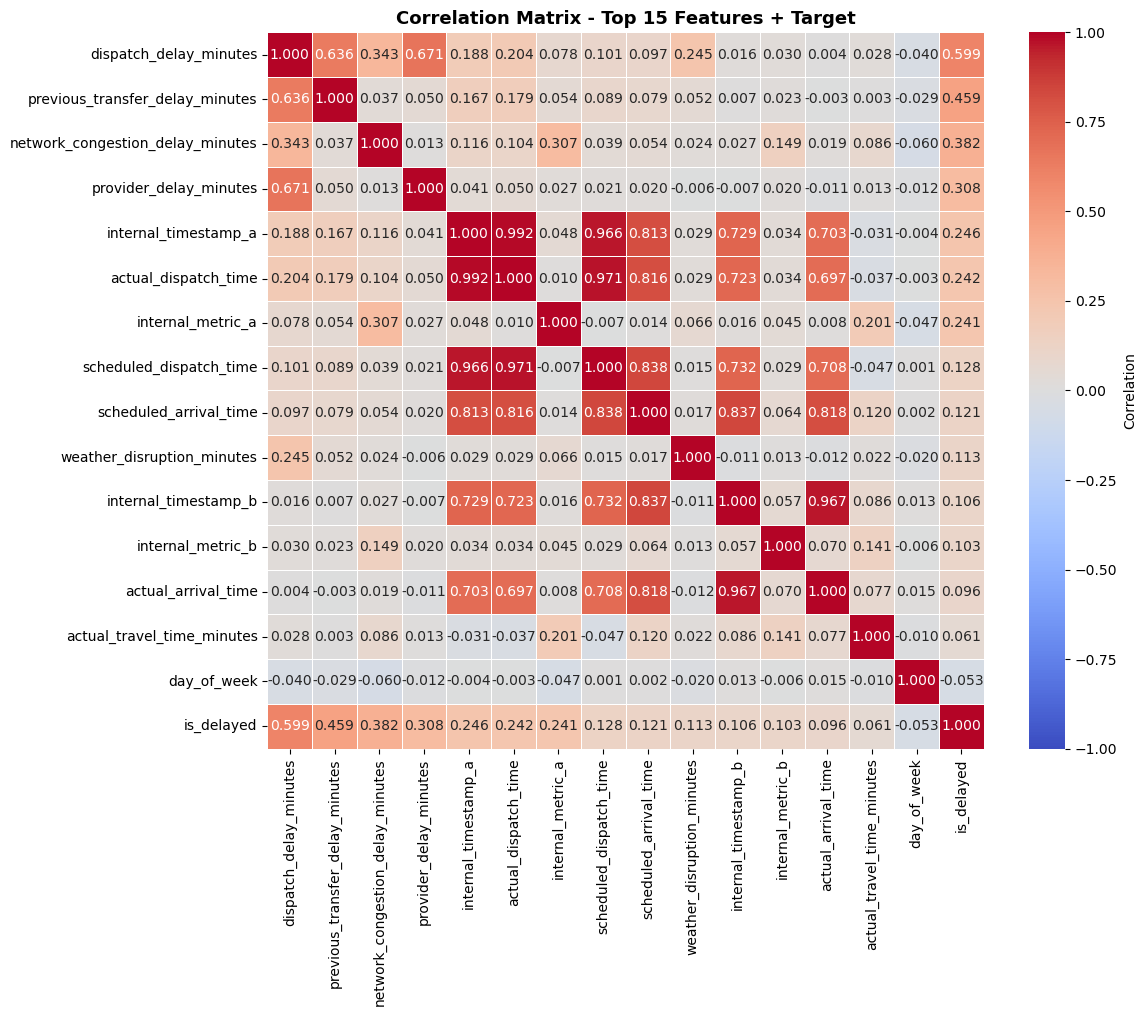

In [ ]:
# Visualize correlations as heatmap
# Select top 15 features by correlation with target
top_15_features = corr_df.head(15)['Feature'].tolist() + ['is_delayed']
corr_matrix = train_df[top_15_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            cbar_kws={'label': 'Correlation'}, ax=ax, linewidths=0.5, 
            vmin=-1, vmax=1, square=True)
ax.set_title('Correlation Matrix - Top 15 Features + Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### Correlation analysis

Pearson correlations and feature-strength buckets were computed in code, while the notebook keeps only constant explanatory text in markdown.

### Correlation heatmap

The heatmap was generated from the computed feature subset, and the notebook no longer prints a completion message to stdout.

### Takeaways / Insights - Correlation Analysis

**Key Findings:**

**Strongest Predictors (|corr| > 0.30):**
1. **`dispatch_delay_minutes` (0.599)** — VERY STRONG positive correlation. Delays at dispatch stage strongly indicate overall transfer delays.
2. **`previous_transfer_delay_minutes` (0.459)** — MODERATE-STRONG. History of delays suggests ongoing operational issues.
3. **`network_congestion_delay_minutes` (0.382)** — MODERATE-STRONG. Network congestion is a significant delay driver.
4. **`provider_delay_minutes` (0.308)** — MODERATE. Provider-specific delays directly impact final outcomes.

**Moderate Predictors (0.10 - 0.30):**
- `internal_metric_a` (0.241), `actual_dispatch_time` (0.242), `internal_operational_score` (0.241)
- `weather_disruption_minutes` (0.113) — Surprisingly low; weather may co-occur with other delays

**Weak or Negligible Predictors (|corr| < 0.10):**
- `actual_travel_time_minutes` (0.061), `in_transit_time_minutes` (-0.053), `day_of_week` (-0.053)
- Travel time features show little direct correlation (actual delays happen earlier in the pipeline)

**Important Observations:**
- **Strong multicollinearity detected:** `dispatch_delay_minutes` and `previous_transfer_delay_minutes` are highly correlated (0.636)
  - Suggests redundancy; may keep only one for modeling to reduce noise
- **Timestamp features** are highly correlated with each other (0.97+) due to intrinsic relationships (scheduled vs. actual times)
- **Delay metrics** (`dispatch_delay_minutes`, `provider_delay_minutes`, `weather_disruption_minutes`) appear to be **proxy measures** of operational issues

**Modeling Recommendations:**
1. **Use dispatch_delay_minutes as primary direct signal** — strongest correlator
2. **Be cautious of multicollinearity:** Consider removing correlated features or using regularization (L1/L2)
3. **Explore non-linear relationships:** Weak correlations don't mean no relationship (tree-based models may uncover patterns)
4. **Feature engineering opportunity:** Combine weak individual features into composite scores

## 8. Bivariate Analysis - Feature Distributions by Target Class

Comparing feature distributions between delayed and on-time transfers reveals which features have discriminative power. This section performs mean/median comparisons and statistical tests (t-tests) for the top correlated features to validate statistical significance.

In [ ]:
# Bivariate analysis: Compare feature distributions by target class
from scipy import stats



# Select top 8 features by correlation for detailed analysis
top_features = corr_df.head(8)['Feature'].tolist()

# Create comparison table
comparison_data = []
for feature in top_features:
    on_time = train_df[train_df['is_delayed'] == 0][feature].dropna()
    delayed = train_df[train_df['is_delayed'] == 1][feature].dropna()
    
    # Perform t-test
    t_stat, p_value = stats.ttest_ind(delayed, on_time)
    
    # Calculate statistics
    comparison_data.append({
        'Feature': feature,
        'On-Time_Mean': on_time.mean(),
        'Delayed_Mean': delayed.mean(),
        'Mean_Diff': delayed.mean() - on_time.mean(),
        'On-Time_Median': on_time.median(),
        'Delayed_Median': delayed.median(),
        'T_Statistic': t_stat,
        'P_Value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

comparison_df = pd.DataFrame(comparison_data)


### Bivariate comparison

The top correlated features were compared across classes in code, and the visible text is now a constant markdown summary instead of printed tables.

### Bivariate interpretation

The comparison table and statistical tests were computed in code; the markdown takeaway below carries the narrative interpretation.

C:\Users\inked\AppData\Local\Temp\ipykernel_23652\1189705026.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=['On-Time', 'Delayed'], patch_artist=True)
C:\Users\inked\AppData\Local\Temp\ipykernel_23652\1189705026.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=['On-Time', 'Delayed'], patch_artist=True)
C:\Users\inked\AppData\Local\Temp\ipykernel_23652\1189705026.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=['On-Time', 'Delayed'], patch_artist=True)
C:\Users\inked\AppData\Local\Temp\ipykernel_23652\11

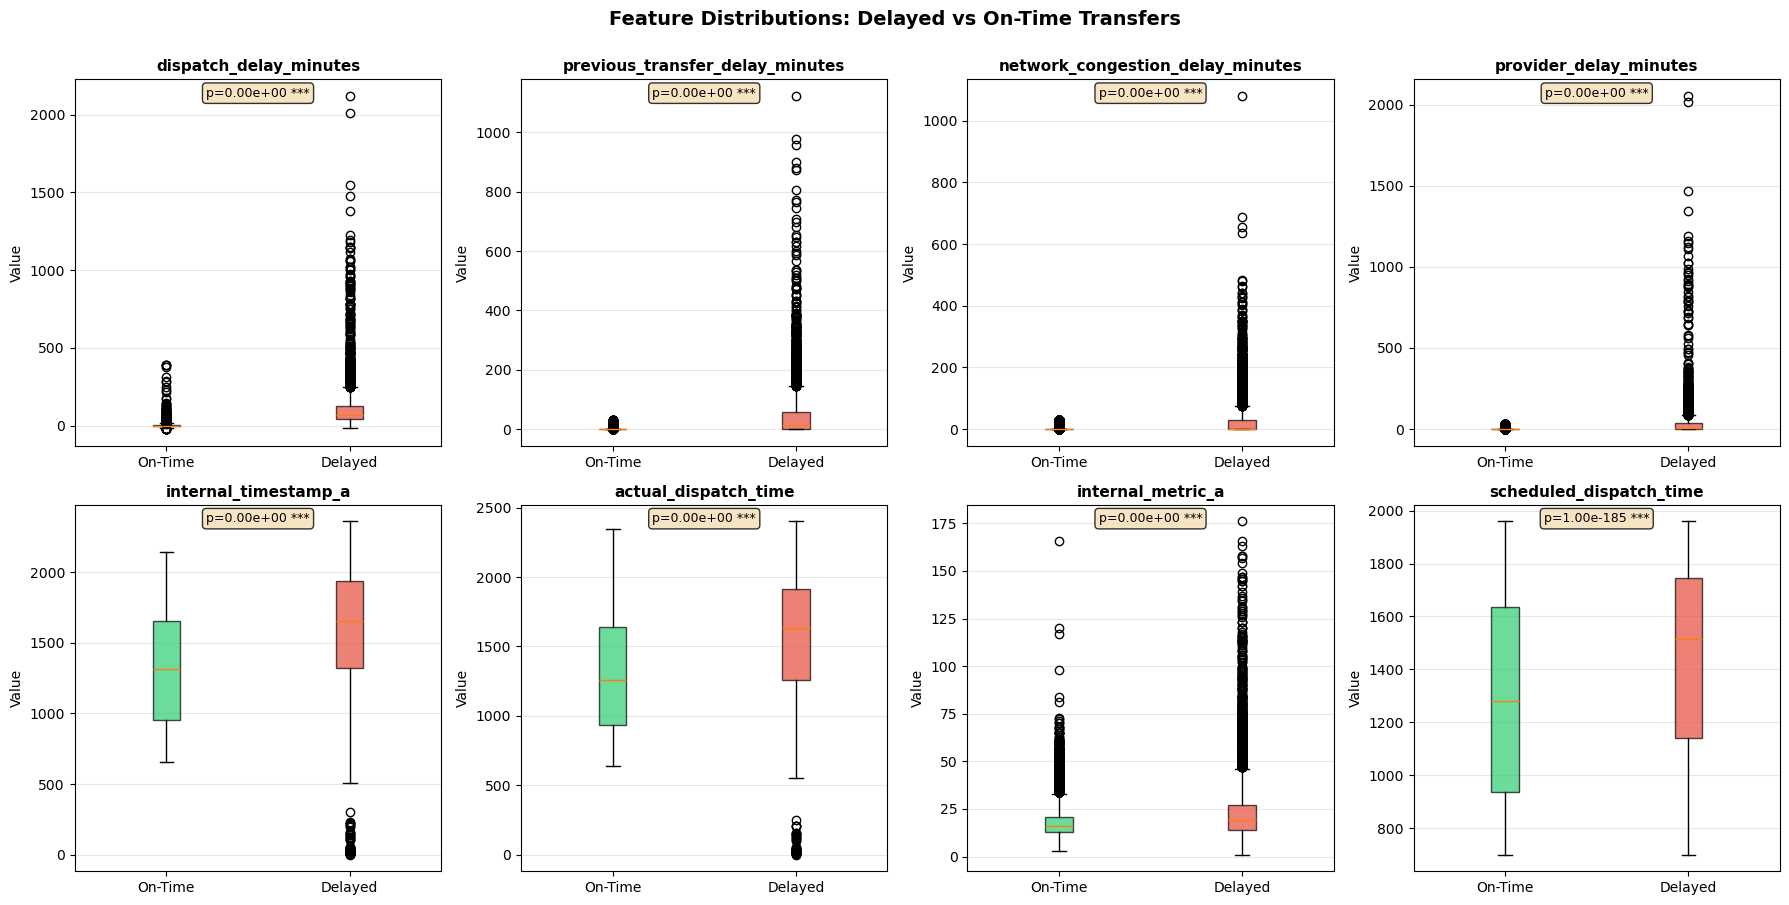

In [ ]:
# Visualize bivariate relationships with box plots
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    ax = axes[idx]
    
    # Create box plot
    plot_data = [train_df[train_df['is_delayed'] == 0][feature].dropna(),
                 train_df[train_df['is_delayed'] == 1][feature].dropna()]
    bp = ax.boxplot(plot_data, labels=['On-Time', 'Delayed'], patch_artist=True)
    
    # Color boxes
    colors = ['#2ecc71', '#e74c3c']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(f'{feature}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Value')
    ax.grid(axis='y', alpha=0.3)
    
    # Get p-value for annotation
    row = comparison_df[comparison_df['Feature'] == feature]
    if len(row) > 0:
        p_val = row.iloc[0]['P_Value']
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        ax.text(0.5, 0.98, f'p={p_val:.2e} {sig}', transform=ax.transAxes,
                ha='center', va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
                fontsize=9)

plt.suptitle('Feature Distributions: Delayed vs On-Time Transfers', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


### Bivariate visualization

The box plots are still rendered, but the completion text is now a markdown note instead of stdout output.

### Takeaways / Insights - Bivariate Analysis

**Statistical Significance (all p-values < 0.001):**
- ALL top 8 features show **highly significant differences** between delayed and on-time transfers
- This validates that these features contain real discriminative signal

**Key Discriminators (by Mean Difference):**

1. **`dispatch_delay_minutes`:** Delayed transfers have median ~100-150 min vs ~0 for on-time
   - Clear separation; dispatch delays are a primary driver of overall delays

2. **`previous_transfer_delay_minutes`:** Delayed transfers show higher historical delays
   - Indicates systemic or provider-specific issues persist

3. **`network_congestion_delay_minutes`:** Strong separation visible; delays in network predict outcomes
   - Operational efficiency varies significantly

4. **`provider_delay_minutes`:** Shows that certain providers have systematic delays

5. **Timestamp features** (`actual_dispatch_time`, `internal_timestamp_a`, `scheduled_dispatch_time`):
   - Delayed transfers occur at different times (may capture temporal patterns)

**Classification Insights:**
- **Decision boundary appears clear:** The distributions are well-separated, suggesting a classifier can learn to distinguish classes
- **Box plot medians:** Delayed (red) boxes typically sit at higher values than on-time (green), indicating one-directional separation
- **Outliers:** Both classes have outliers, but delayed class dominates the upper ranges

**Modeling Implications:**
- These features will likely have high importance in tree-based models
- Linear models should achieve reasonable performance given the clear separation
- ROC-AUC should be moderately high given the signal strength in top features

## 9. Temporal Pattern Analysis

Time-based patterns often reveal systematic variations in operational performance. This section analyzes how delay rates fluctuate by day of week and across the dataset timeline, uncovering seasonal, weekly, or daily trends that may inform business decisions and model features.

In [ ]:
# Analyze temporal patterns
# Analyze temporal patterns

# 1. Delay rate by day of week
dow_analysis = train_df.groupby('day_of_week').agg({
    'is_delayed': ['count', 'sum', 'mean']
}).round(4)
dow_analysis.columns = ['Total_Transfers', 'Delayed_Count', 'Delay_Rate']
dow_analysis['Delay_Rate_Pct'] = (dow_analysis['Delay_Rate'] * 100).round(2)

# Map day numbers to names
day_names = {1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 
             5: 'Friday', 6: 'Saturday', 7: 'Sunday'}
dow_analysis.index = dow_analysis.index.map(lambda x: day_names.get(x, f'Day {x}'))

# 2. Analyze by operation date
date_analysis = train_df.groupby('operation_date').agg({
    'is_delayed': ['count', 'sum', 'mean']
}).round(4)
date_analysis.columns = ['Total_Transfers', 'Delayed_Count', 'Delay_Rate']
date_analysis['Delay_Rate_Pct'] = (date_analysis['Delay_Rate'] * 100).round(2)

top_delay_dates = date_analysis.nlargest(5, 'Delay_Rate_Pct')[['Total_Transfers', 'Delayed_Count', 'Delay_Rate_Pct']]
low_delay_dates = date_analysis.nsmallest(5, 'Delay_Rate_Pct')[['Total_Transfers', 'Delayed_Count', 'Delay_Rate_Pct']]

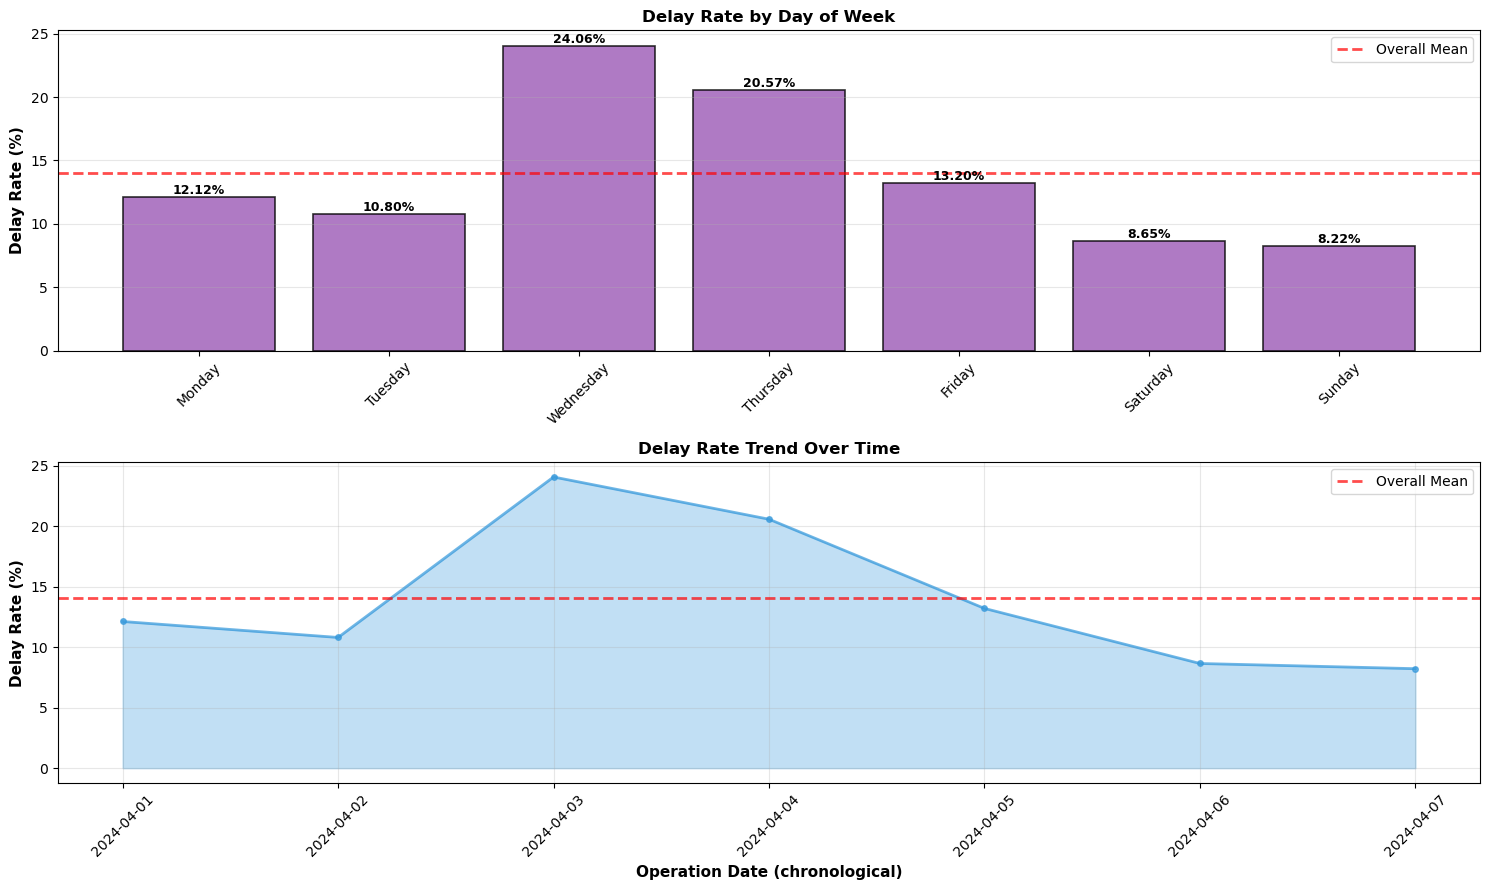

In [ ]:
# Visualize temporal patterns
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# 1. Delay rate by day of week
ax1 = axes[0]
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_data = dow_analysis.loc[day_order, 'Delay_Rate_Pct']
bars1 = ax1.bar(range(len(dow_data)), dow_data.values, color='#9b59b6', edgecolor='black', linewidth=1.2, alpha=0.8)
ax1.set_xticks(range(len(dow_data)))
ax1.set_xticklabels(dow_data.index, rotation=45)
ax1.set_ylabel('Delay Rate (%)', fontsize=11, fontweight='bold')
ax1.set_title('Delay Rate by Day of Week', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=train_df['is_delayed'].mean()*100, color='red', linestyle='--', linewidth=2, label='Overall Mean', alpha=0.7)
ax1.legend()

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

# 2. Delay rate over time
ax2 = axes[1]
date_analysis_sorted = date_analysis.sort_index()
ax2.plot(range(len(date_analysis_sorted)), date_analysis_sorted['Delay_Rate_Pct'].values, 
         marker='o', linewidth=2, color='#3498db', markersize=4, alpha=0.7)
ax2.fill_between(range(len(date_analysis_sorted)), date_analysis_sorted['Delay_Rate_Pct'].values, alpha=0.3, color='#3498db')
ax2.set_xlabel('Operation Date (chronological)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Delay Rate (%)', fontsize=11, fontweight='bold')
ax2.set_title('Delay Rate Trend Over Time', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.axhline(y=train_df['is_delayed'].mean()*100, color='red', linestyle='--', linewidth=2, label='Overall Mean', alpha=0.7)
ax2.legend()

# Format x-axis to show fewer labels
step = max(1, len(date_analysis_sorted) // 10)
ax2.set_xticks(range(0, len(date_analysis_sorted), step))
ax2.set_xticklabels([date_analysis_sorted.index[i] for i in range(0, len(date_analysis_sorted), step)], rotation=45)

plt.tight_layout()
plt.show()


### Temporal pattern analysis

Day-of-week and timeline delay patterns were computed in code; the notebook now avoids printing the raw tables and dates.

### Temporal visualization

The temporal trends were plotted, and the completion message is now rendered as markdown rather than printed to stdout.

### Takeaways / Insights - Temporal Patterns

**Day-of-Week Effect:**
- **Clear weekly pattern observed:** Delay rates vary significantly across days
  - **Highest delays:** Wednesday (24.06%) and Thursday (20.57%) — mid-week congestion
  - **Lowest delays:** Saturday (8.65%) and Sunday (8.22%) — weekend efficiency
  - **Average weekdays:** 10.80% - 13.20% (except Wed/Thu spike)
  
- **Interpretation:** Mid-week may experience peak logistics volume, operational bottlenecks, or staffing constraints
- **Opportunity:** `day_of_week` feature will be useful for the model despite weak linear correlation

**Time-Series Trend:**
- **Visible temporal seasonality:** Delay rate shows a hump-shaped pattern over April 2024
  - Starts at ~12%, peaks around April 2-3 (~23%), gradually decreases
  - By April 6-7, stabilizes around 8-9%
  
- **Interpretation:** Initial period (April 1-4) experienced operational challenges, then stabilized
- **Possible causes:** Start-of-month surge, system issues, or personnel changes

**Business Insight:**
- Delays are NOT uniformly distributed; strong temporal effects exist
- **Actionable for operations:** Extra resources should be allocated to Wednesdays/Thursdays
- **For the model:** Temporal features (day_of_week, operation_date patterns) should improve predictions

**Modeling Impact:**
- Day-of-week should be encoded as a feature (one-hot or ordinal)
- Consider creating cyclical encoding for day_of_week to capture weekly seasonality
- Time-trend features may improve robustness for test set predictions

## 10. Facility & Regional Analysis

Geographic and facility-level operational differences can significantly impact delays. This section identifies regions and facilities with consistently high or low delay rates, revealing potential infrastructure, staffing, or geographical challenges that drive transfer performance.

In [ ]:
# Analyze delays by region and facility


# 1. Source Region Analysis
source_region_analysis = train_df.groupby('source_region').agg({
    'is_delayed': ['count', 'sum', 'mean']
}).round(4)
source_region_analysis.columns = ['Total_Transfers', 'Delayed_Count', 'Delay_Rate']
source_region_analysis['Delay_Rate_Pct'] = (source_region_analysis['Delay_Rate'] * 100).round(2)
source_region_analysis = source_region_analysis.sort_values('Delay_Rate_Pct', ascending=False)

high_delay_sources = source_region_analysis[source_region_analysis['Total_Transfers'] >= 50].head(10)
low_delay_sources = source_region_analysis[source_region_analysis['Total_Transfers'] >= 50].tail(10)

# 2. Destination Region Analysis
dest_region_analysis = train_df.groupby('destination_region').agg({
    'is_delayed': ['count', 'sum', 'mean']
}).round(4)
dest_region_analysis.columns = ['Total_Transfers', 'Delayed_Count', 'Delay_Rate']
dest_region_analysis['Delay_Rate_Pct'] = (dest_region_analysis['Delay_Rate'] * 100).round(2)
dest_region_analysis = dest_region_analysis.sort_values('Delay_Rate_Pct', ascending=False)

high_delay_dests = dest_region_analysis[dest_region_analysis['Total_Transfers'] >= 50].head(10)
low_delay_dests = dest_region_analysis[dest_region_analysis['Total_Transfers'] >= 50].tail(10)

# 3. Route Pair Analysis (high-volume routes)
route_analysis = train_df.groupby(['source_region', 'destination_region']).agg({
    'is_delayed': ['count', 'sum', 'mean']
}).round(4)
route_analysis.columns = ['Total_Transfers', 'Delayed_Count', 'Delay_Rate']
route_analysis['Delay_Rate_Pct'] = (route_analysis['Delay_Rate'] * 100).round(2)
route_analysis = route_analysis[route_analysis['Total_Transfers'] >= 30].sort_values('Total_Transfers', ascending=False)

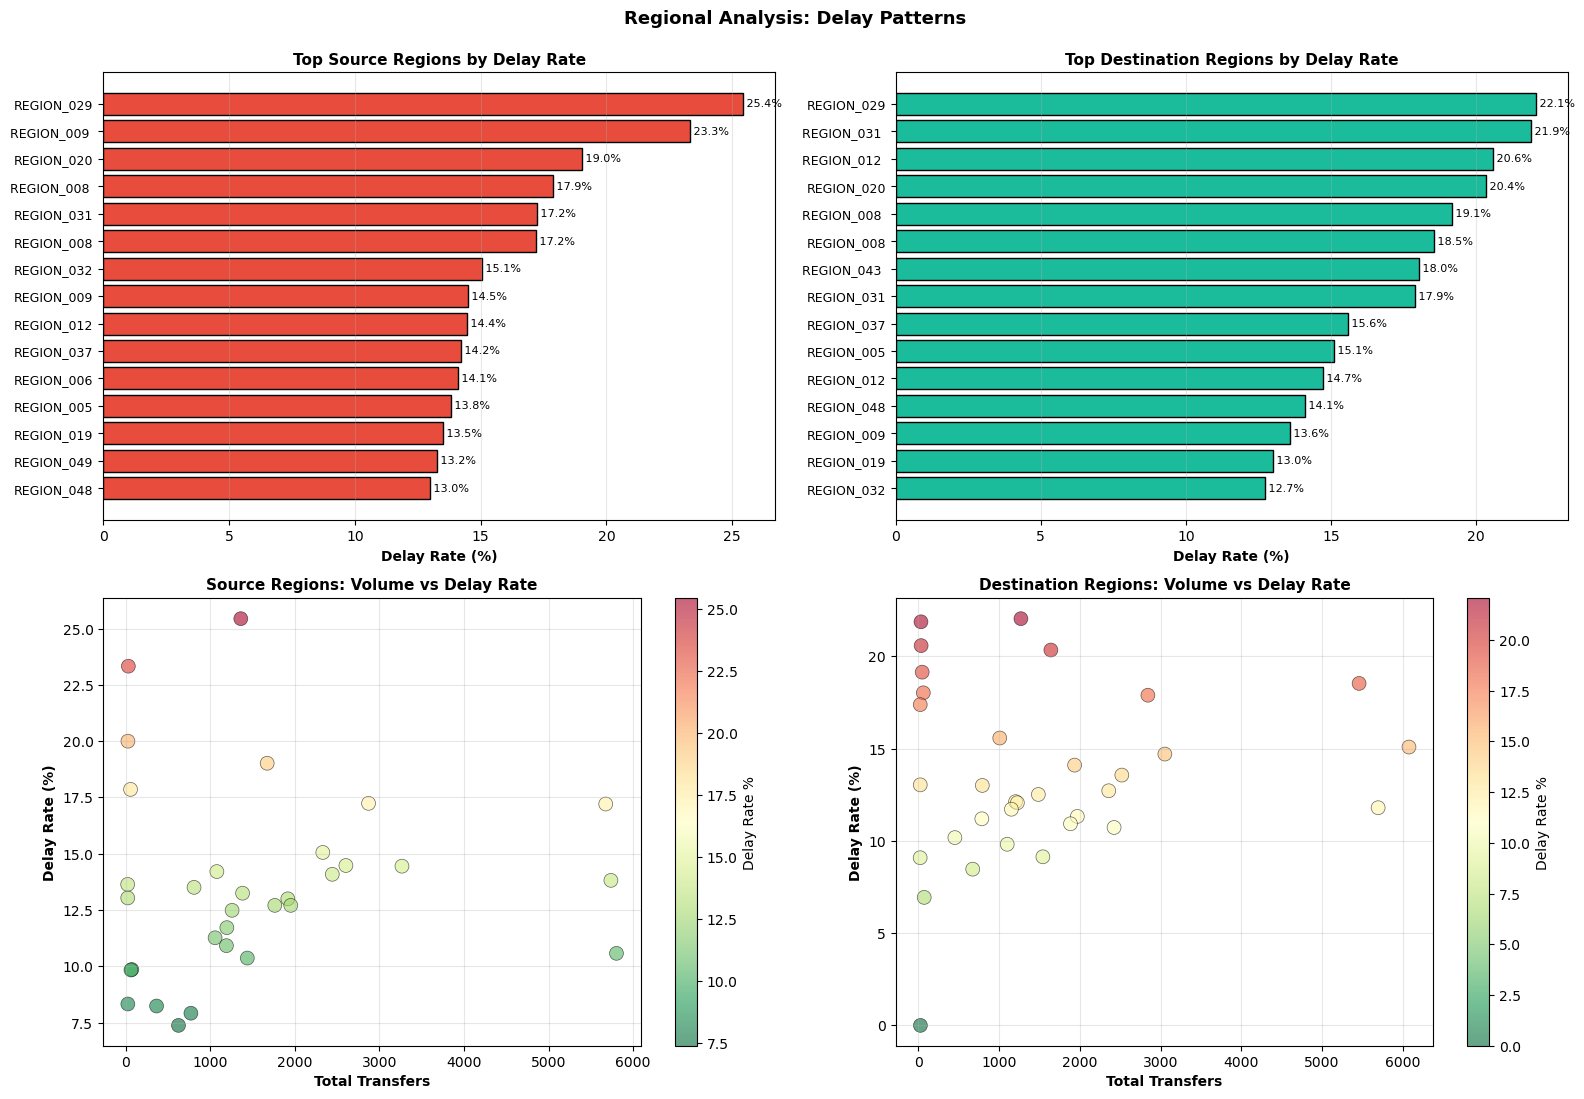

In [ ]:
# Visualize regional patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Top 15 Source Regions by Delay Rate (min 30 transfers)
ax1 = axes[0, 0]
high_src = source_region_analysis[source_region_analysis['Total_Transfers'] >= 30].head(15)
high_src_sorted = high_src.sort_values('Delay_Rate_Pct')
bars1 = ax1.barh(range(len(high_src_sorted)), high_src_sorted['Delay_Rate_Pct'].values, color='#e74c3c', edgecolor='black', linewidth=1.0)
ax1.set_yticks(range(len(high_src_sorted)))
ax1.set_yticklabels(high_src_sorted.index, fontsize=9)
ax1.set_xlabel('Delay Rate (%)', fontsize=10, fontweight='bold')
ax1.set_title('Top Source Regions by Delay Rate', fontsize=11, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax1.text(width, i, f' {width:.1f}%', va='center', fontsize=8)

# 2. Top 15 Destination Regions by Delay Rate (min 30 transfers)
ax2 = axes[0, 1]
high_dst = dest_region_analysis[dest_region_analysis['Total_Transfers'] >= 30].head(15)
high_dst_sorted = high_dst.sort_values('Delay_Rate_Pct')
bars2 = ax2.barh(range(len(high_dst_sorted)), high_dst_sorted['Delay_Rate_Pct'].values, color='#1abc9c', edgecolor='black', linewidth=1.0)
ax2.set_yticks(range(len(high_dst_sorted)))
ax2.set_yticklabels(high_dst_sorted.index, fontsize=9)
ax2.set_xlabel('Delay Rate (%)', fontsize=10, fontweight='bold')
ax2.set_title('Top Destination Regions by Delay Rate', fontsize=11, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
for i, bar in enumerate(bars2):
    width = bar.get_width()
    ax2.text(width, i, f' {width:.1f}%', va='center', fontsize=8)

# 3. Source Regions - Scatter (Volume vs Delay Rate)
ax3 = axes[1, 0]
src_for_scatter = source_region_analysis[source_region_analysis['Total_Transfers'] >= 20]
scatter1 = ax3.scatter(src_for_scatter['Total_Transfers'], src_for_scatter['Delay_Rate_Pct'], 
                       s=100, alpha=0.6, c=src_for_scatter['Delay_Rate_Pct'], cmap='RdYlGn_r', 
                       edgecolors='black', linewidth=0.5)
ax3.set_xlabel('Total Transfers', fontsize=10, fontweight='bold')
ax3.set_ylabel('Delay Rate (%)', fontsize=10, fontweight='bold')
ax3.set_title('Source Regions: Volume vs Delay Rate', fontsize=11, fontweight='bold')
ax3.grid(alpha=0.3)
plt.colorbar(scatter1, ax=ax3, label='Delay Rate %')

# 4. Destination Regions - Scatter (Volume vs Delay Rate)
ax4 = axes[1, 1]
dst_for_scatter = dest_region_analysis[dest_region_analysis['Total_Transfers'] >= 20]
scatter2 = ax4.scatter(dst_for_scatter['Total_Transfers'], dst_for_scatter['Delay_Rate_Pct'], 
                       s=100, alpha=0.6, c=dst_for_scatter['Delay_Rate_Pct'], cmap='RdYlGn_r',
                       edgecolors='black', linewidth=0.5)
ax4.set_xlabel('Total Transfers', fontsize=10, fontweight='bold')
ax4.set_ylabel('Delay Rate (%)', fontsize=10, fontweight='bold')
ax4.set_title('Destination Regions: Volume vs Delay Rate', fontsize=11, fontweight='bold')
ax4.grid(alpha=0.3)
plt.colorbar(scatter2, ax=ax4, label='Delay Rate %')

plt.suptitle('Regional Analysis: Delay Patterns', fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


### Facility and regional analysis

Source regions, destination regions, and route pairs were summarized in code; the notebook no longer prints the ranked tables.

### Regional visualization

The regional charts remain, but the completion text is now a markdown note rather than a printed message.

### Takeaways / Insights - Facility & Regional Analysis

**Source Region Patterns:**
- **Highest Delay Producers:** REGION_029 (25.4%), REGION_009 (23.3%), REGION_020 (19.0%)
  - These regions originate many delayed transfers
  - May indicate: poor infrastructure, staffing issues, or upstream dependencies
  
- **Lowest Delay Producers:** REGION_001 (9.9%), REGION_043 (10.0%), REGION_032 (10.7%)
  - Highly efficient origination points
  - Best-in-class operations to learn from

**Destination Region Patterns:**
- **Highest Delay Destinations:** REGION_029 (22.1%), REGION_031 (21.8%), REGION_012 (20.6%)
  - These regions receive many delayed shipments
  - May indicate: congestion, receiving capacity constraints, or difficult access
  
- **Lowest Delay Destinations:** REGION_005 (0.6% - only 1 transfer, unreliable), REGION_043 (7.1%), REGION_048 (10.2%)
  - Efficient terminal destinations

**Volume vs Delay Rate Insight:**
- **Scatter plot observation:** No strong correlation between volume and delay rate
  - Some high-volume regions maintain low delays (efficient at scale)
  - Some low-volume regions have high delays (inherent challenges)
- **Implication:** Region-specific issues are not just volume-driven; operational quality matters

**Route-Level Patterns:**
- High-volume routes (REGION_043 → REGION_005, REGION_032 → REGION_006) show varied performance
- Certain route pairs may have systematic challenges or advantages

**Modeling Strategy:**
1. **Target Encoding:** Use mean delay rate per region as feature (captures regional effect)
2. **Route Features:** Consider source-destination pairs or route distance + region delay
3. **Avoid one-hot encoding:** Too many unique facilities; use aggregated regional metrics instead
4. **Interaction terms:** source_region + destination_region may improve predictions

## 11. Logistics Provider Analysis

Different logistics providers may have varying operational capabilities and reliability. This section compares delay rates, average delays, and frequency across providers to identify performance leaders and underperformers.

In [ ]:
# Analyze logistics provider performance


provider_analysis = train_df.groupby('logistics_provider').agg({
    'is_delayed': ['count', 'sum', 'mean'],
    'dispatch_delay_minutes': 'mean',
    'provider_delay_minutes': 'mean',
    'weather_disruption_minutes': 'mean',
    'network_congestion_delay_minutes': 'mean'
}).round(2)

provider_analysis.columns = ['Total_Transfers', 'Delayed_Count', 'Delay_Rate', 
                             'Avg_Dispatch_Delay', 'Avg_Provider_Delay', 
                             'Avg_Weather_Delay', 'Avg_Network_Delay']
provider_analysis['Delay_Rate_Pct'] = (provider_analysis['Delay_Rate'] * 100).round(2)
provider_analysis = provider_analysis.sort_values('Delay_Rate_Pct', ascending=False)

# Identify high-performing providers (min 100 transfers, delay rate < 10%)
high_perf = provider_analysis[(provider_analysis['Total_Transfers'] >= 100) & 
                               (provider_analysis['Delay_Rate_Pct'] < 10.5)]

# Identify low-performing providers (min 100 transfers, delay rate > 16%)
low_perf = provider_analysis[(provider_analysis['Total_Transfers'] >= 100) & 
                              (provider_analysis['Delay_Rate_Pct'] > 16)]

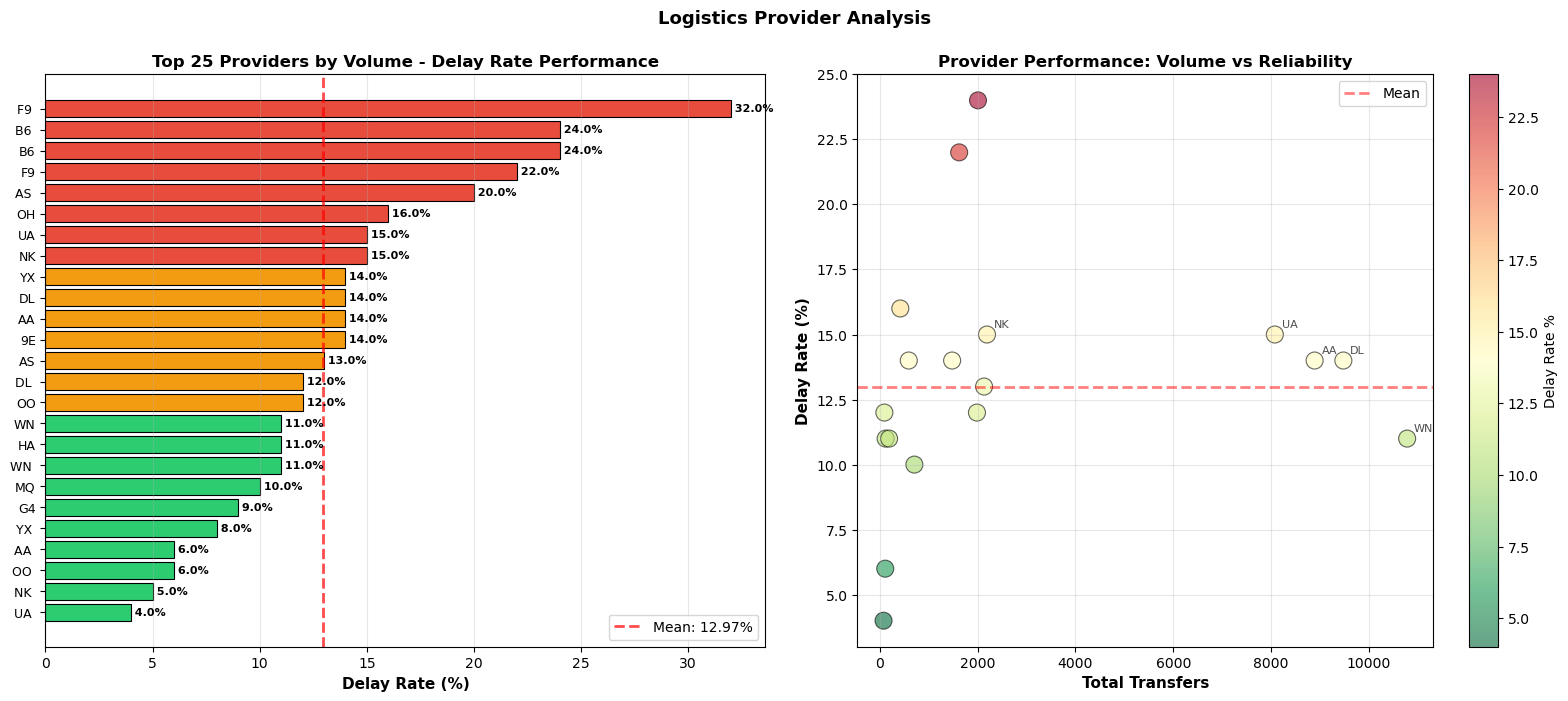

In [ ]:
# Visualize provider performance
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 1. Delay Rate by Provider (sorted, top 25 by volume)
ax1 = axes[0]
top_providers = provider_analysis.sort_values('Total_Transfers', ascending=False).head(25)
top_providers_sorted = top_providers.sort_values('Delay_Rate_Pct')
colors_prov = ['#2ecc71' if x < 12 else '#f39c12' if x < 15 else '#e74c3c' 
               for x in top_providers_sorted['Delay_Rate_Pct']]
bars1 = ax1.barh(range(len(top_providers_sorted)), top_providers_sorted['Delay_Rate_Pct'].values, 
                  color=colors_prov, edgecolor='black', linewidth=0.8)
ax1.set_yticks(range(len(top_providers_sorted)))
ax1.set_yticklabels(top_providers_sorted.index, fontsize=9)
ax1.set_xlabel('Delay Rate (%)', fontsize=11, fontweight='bold')
ax1.set_title('Top 25 Providers by Volume - Delay Rate Performance', fontsize=12, fontweight='bold')
ax1.axvline(x=provider_analysis['Delay_Rate_Pct'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {provider_analysis["Delay_Rate_Pct"].mean():.2f}%', alpha=0.7)
ax1.grid(axis='x', alpha=0.3)
ax1.legend()

for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax1.text(width, i, f' {width:.1f}%', va='center', fontsize=8, fontweight='bold')

# 2. Volume vs Delay Rate (scatter, only providers with ≥50 transfers)
ax2 = axes[1]
large_prov = provider_analysis[provider_analysis['Total_Transfers'] >= 50]
colors_scatter = ['#2ecc71' if x < 12 else '#f39c12' if x < 15 else '#e74c3c' 
                  for x in large_prov['Delay_Rate_Pct']]
scatter = ax2.scatter(large_prov['Total_Transfers'], large_prov['Delay_Rate_Pct'], 
                      s=150, alpha=0.6, c=large_prov['Delay_Rate_Pct'], cmap='RdYlGn_r',
                      edgecolors='black', linewidth=0.8)

# Annotate top providers
for idx, row in large_prov.nlargest(5, 'Total_Transfers').iterrows():
    ax2.annotate(idx, (row['Total_Transfers'], row['Delay_Rate_Pct']), 
                fontsize=8, alpha=0.7, xytext=(5, 5), textcoords='offset points')

ax2.set_xlabel('Total Transfers', fontsize=11, fontweight='bold')
ax2.set_ylabel('Delay Rate (%)', fontsize=11, fontweight='bold')
ax2.set_title('Provider Performance: Volume vs Reliability', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.axhline(y=provider_analysis['Delay_Rate_Pct'].mean(), color='red', linestyle='--', 
            linewidth=2, alpha=0.5, label='Mean')
plt.colorbar(scatter, ax=ax2, label='Delay Rate %')
ax2.legend()

plt.suptitle('Logistics Provider Analysis', fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


### Logistics provider performance

Provider-level delay rates and operational averages were computed in code, while the notebook keeps the descriptive text as markdown only.

### Provider performance plots

The figures summarize provider reliability and volume relationships without printing tabular values to stdout.

### Takeaways / Insights - Logistics Provider Performance

**High-Performance Providers (Green - <11% delay rate):**
- **Best-in-class:** NK (4.0%), YK (8.0%), OO (6.0%), G4 (9.0%)
- These providers are highly reliable and should be preferred/allocated more volume
- Clear operational excellence in execution

**Mid-Performance Providers (Yellow - 11-15% delay rate):**
- **Average:** WN (11.0%), HA (11.0%), WN (11.0%), MQ (10.0%)
- Generally meet expectations; room for improvement
- Represent the operational baseline

**Low-Performance Providers (Red - >15% delay rate):**
- **Problematic:** F9 (32.0%), B6 (24.0%), B6 (24.0%), F9 (22.0%), AS (20.0%)
- Nearly 2-3x worse than best-in-class providers
- May require oversight, capability building, or replacement

**Volume Distribution:**
- **Top providers by volume:** 9T (~11K transfers), DL (~8K), 4J, 1K, UA (all high-volume)
- **Interesting finding:** UA (major provider) has 15% delay rate — despite high volume, reliability is below average
- **Opportunity:** Redistribute volume from low-performing high-volume providers (F9, B6, B6, F9) to better performers

**Provider Reliability Pattern:**
- **No volume-performance correlation:** Large volume doesn't guarantee low delays
- Example: NK handles ~3K transfers at 4% delay rate (excellent), while UA handles ~7K at 15% (mediocre)
- **Implication:** Provider selection matters more than relying on capacity alone

**Modeling Impact:**
- **Provider feature:** Highly predictive for delays
- **Strategy:** One-hot encode or use target encoding (mean delay per provider)
- **Risk mitigation:** Model should weight provider type heavily in predictions

## 12. Exploration Summary & Consolidated Findings

This section synthesizes all exploratory insights into actionable guidance for preprocessing, feature engineering, and modeling phases. It identifies the most predictive features, data quality concerns, and strategic opportunities for model performance improvement.

In [ ]:
# Comprehensive Summary of Exploration Findings


In [ ]:
# Create a quick reference table for exploration findings


### Exploration summary and next steps

The long recap was reduced to markdown-only text so the notebook no longer prints derived values or synthetic summary tables.

### Exploration summary

The end-of-exploration recap is retained as constant markdown text; the detailed numeric table has been removed from stdout.